# HW03

## 2. 卷积和池化层

### 2.1 理论计算题

卷积输出的空间尺寸公式为

$$
H_{\mathrm{out}}
=\left\lfloor\frac{H_{\mathrm{in}}+2P-K}{S}\right\rfloor+1,
\qquad
W_{\mathrm{out}}
=\left\lfloor\frac{W_{\mathrm{in}}+2P-K}{S}\right\rfloor+1.
$$

代入 $H_{\mathrm{in}}=W_{\mathrm{in}}=32$、$P=2$、$K=5$、$S=2$：

$$
H_{\mathrm{out}}=W_{\mathrm{out}}
=\left\lfloor\frac{32+2\times2-5}{2}\right\rfloor+1
=16.
$$

卷积层包含 16 个卷积核，因此输出特征图尺寸为

$$
\boxed{16\times16\times16}\quad(\text{通道数}\times\text{高}\times\text{宽}).
$$

单个输出通道的一个像素值由一个 $3\times5\times5$ 卷积核与对应输入窗口点乘得到，所以需要

$$
\boxed{3\times5\times5=75}
$$

次乘法（若计算偏置，只需额外一次加法，不增加乘法次数）。

### 2.2 编程题：手动实现二维最大池化

下面仅使用 PyTorch 的基础张量操作实现最大池化，不调用 `torch.nn.MaxPool2d` 或
`torch.nn.functional.max_pool2d`。函数支持二维输入，以及带批次和通道维度的三维、四维输入。

In [1]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


def _pair(value):
    if isinstance(value, int):
        return (value, value)
    if len(value) != 2:
        raise ValueError("kernel_size, stride and padding must be int or length-2 tuple")
    return tuple(value)


def manual_max_pool2d(X, kernel_size, stride=None, padding=0):
    kernel_h, kernel_w = _pair(kernel_size)
    stride_h, stride_w = _pair(kernel_size if stride is None else stride)
    pad_h, pad_w = _pair(padding)

    original_dim = X.dim()
    if original_dim == 2:
        X = X.unsqueeze(0).unsqueeze(0)
    elif original_dim == 3:
        X = X.unsqueeze(0)
    elif original_dim != 4:
        raise ValueError("X must have shape (H,W), (C,H,W), or (N,C,H,W)")

    if not X.is_floating_point():
        X = X.float()

    # 用基础张量操作填充负无穷，避免调用任何框架 Pooling API。
    n, c, height, width = X.shape
    X_pad = torch.full(
        (n, c, height + 2 * pad_h, width + 2 * pad_w),
        fill_value=float("-inf"),
        dtype=X.dtype,
        device=X.device,
    )
    X_pad[:, :, pad_h : pad_h + height, pad_w : pad_w + width] = X
    n, c, padded_h, padded_w = X_pad.shape
    out_h = (padded_h - kernel_h) // stride_h + 1
    out_w = (padded_w - kernel_w) // stride_w + 1
    output = torch.empty((n, c, out_h, out_w), dtype=X.dtype, device=X.device)

    for i in range(out_h):
        h_start = i * stride_h
        for j in range(out_w):
            w_start = j * stride_w
            window = X_pad[
                :, :, h_start : h_start + kernel_h, w_start : w_start + kernel_w
            ]
            output[:, :, i, j] = window.amax(dim=(-2, -1))

    if original_dim == 2:
        return output[0, 0]
    if original_dim == 3:
        return output[0]
    return output


X_pool = torch.tensor(
    [
        [1.0, 3.0, 2.0, 0.0],
        [4.0, 6.0, 5.0, 1.0],
        [7.0, 2.0, 8.0, 3.0],
        [0.0, 9.0, 4.0, 5.0],
    ]
)

pooled_no_padding = manual_max_pool2d(X_pool, kernel_size=2, stride=2)
pooled_with_padding = manual_max_pool2d(
    X_pool, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)
)

print("input:")
print(X_pool)
print("\n2x2 pooling, stride=2:")
print(pooled_no_padding)
print("\n3x3 pooling, stride=2, padding=1:")
print(pooled_with_padding)

assert torch.equal(
    pooled_no_padding, torch.tensor([[6.0, 5.0], [9.0, 8.0]])
)
print("\nmanual max pooling check passed")

input:
tensor([[1., 3., 2., 0.],
        [4., 6., 5., 1.],
        [7., 2., 8., 3.],
        [0., 9., 4., 5.]])

2x2 pooling, stride=2:
tensor([[6., 5.],
        [9., 8.]])

3x3 pooling, stride=2, padding=1:
tensor([[6., 6.],
        [9., 9.]])

manual max pooling check passed


---

## 3. LeNet、AlexNet、VGG 和 NiN

### 3.1 理论计算题

输入和输出通道数都为 $C$，且不带偏置时：

1. 一个 $5\times5$ 卷积层的参数量为

$$
C\times C\times5\times5=\boxed{25C^2}.
$$

2. 两个串联的 $3\times3$ 卷积层，每层参数量均为 $9C^2$，总参数量为

$$
2\times C\times C\times3\times3=\boxed{18C^2}.
$$

两个 $3\times3$ 卷积串联后具有与一个 $5\times5$ 卷积相同的理论感受野，但参数量减少

$$
25C^2-18C^2=7C^2,
$$

即减少 $7/25=28\%$，并且中间多引入一次非线性激活。

### 3.2 编程题：NiN Block

标准 NiN 块由一个普通卷积层、两个 $1\times1$ 卷积层组成，每个卷积层后紧跟 ReLU。

In [2]:
def nin_block(in_channels, out_channels, kernel_size, stride, padding):
    return nn.Sequential(
        nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
        ),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(),
    )


nin = nin_block(
    in_channels=3,
    out_channels=16,
    kernel_size=5,
    stride=2,
    padding=2,
)
X_nin = torch.randn(4, 3, 32, 32)
Y_nin = nin(X_nin)

print(nin)
print("input shape: ", tuple(X_nin.shape))
print("output shape:", tuple(Y_nin.shape))

assert Y_nin.shape == (4, 16, 16, 16)
print("NiN block shape check passed")

Sequential(
  (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (1): ReLU()
  (2): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (3): ReLU()
  (4): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (5): ReLU()
)
input shape:  (4, 3, 32, 32)
output shape: (4, 16, 16, 16)
NiN block shape check passed


---

## 4. Inception、批量归一化和残差网络

### 4.1 理论计算题

训练阶段 Batch Normalization 对当前 mini-batch 计算均值和方差。这里

$$
\mu_B=\frac{2+4+6+8}{4}=5,
$$

$$
\sigma_B^2=\frac{(2-5)^2+(4-5)^2+(6-5)^2+(8-5)^2}{4}=5.
$$

由

$$
\hat{x}_i=\frac{x_i-\mu_B}{\sqrt{\sigma_B^2+\epsilon}},
\qquad
y_i=\gamma\hat{x}_i+\beta
$$

以及 $\gamma=2,\beta=1,\epsilon=0$，得到

$$
(y_1,y_2,y_3,y_4)
=\left(
1-\frac{6}{\sqrt5},
1-\frac{2}{\sqrt5},
1+\frac{2}{\sqrt5},
1+\frac{6}{\sqrt5}
\right).
$$

数值约为

$$
\boxed{(-1.6833,\ 0.1056,\ 1.8944,\ 3.6833)}.
$$

### 4.2 编程题：Residual Block

残差块包含两个输出通道数相同的 $3\times3$ 卷积层，每层后接 BatchNorm。
第一层卷积后使用 ReLU，第二层与捷径分支相加后再使用 ReLU。当尺寸或通道数变化时，
用可选的 $1\times1$ 卷积调整捷径分支。

In [3]:
class Residual(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        use_1x1conv=False,
        strides=1,
    ):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            stride=strides,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = (
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                stride=strides,
                bias=False,
            )
            if use_1x1conv
            else None
        )

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        shortcut = self.conv3(X) if self.conv3 is not None else X
        return F.relu(Y + shortcut)


X_res = torch.randn(4, 3, 32, 32)
same_shape_block = Residual(3, 3)
downsample_block = Residual(3, 6, use_1x1conv=True, strides=2)

Y_same = same_shape_block(X_res)
Y_down = downsample_block(X_res)

print("same-shape residual:", tuple(X_res.shape), "->", tuple(Y_same.shape))
print("1x1 shortcut residual:", tuple(X_res.shape), "->", tuple(Y_down.shape))

assert Y_same.shape == (4, 3, 32, 32)
assert Y_down.shape == (4, 6, 16, 16)
print("Residual block shape checks passed")

same-shape residual: (4, 3, 32, 32) -> (4, 3, 32, 32)
1x1 shortcut residual: (4, 3, 32, 32) -> (4, 6, 16, 16)
Residual block shape checks passed


---

## 5. 图像增广、微调和样式迁移

### 5.1 理论计算题

1. 预训练模型的底层和中层已经学习到边缘、纹理、局部形状等可迁移的通用特征。
   对这些层使用较小学习率，可以避免目标数据较少时破坏已有的有效表示；
   最终输出层与新任务的类别数和语义直接相关，通常是随机初始化的，因此需要更大的学习率快速适配。

2. 当目标数据集非常小且与源数据集很相似时，应优先冻结大部分甚至全部特征提取层，
   只训练新初始化的分类输出层。可以配合数据增广、权重衰减和早停；
   若验证集表现显示仍需适配，再以很小的学习率逐步解冻靠近输出端的少数高层。
   这样既利用预训练特征，又降低小数据集上的过拟合风险。

### 5.2 编程题：图像增广 Pipeline

管道依次执行随机裁剪缩放、随机水平翻转、颜色抖动和张量转换。
下面用一张程序生成的 RGB 渐变图演示，因此不依赖外部图片文件。

original image size: (320, 240)
augmented 1: shape=(3, 224, 224), range=(0.031, 0.451)
augmented 2: shape=(3, 224, 224), range=(0.761, 1.000)
augmented 3: shape=(3, 224, 224), range=(0.192, 0.741)
augmented 4: shape=(3, 224, 224), range=(0.337, 0.655)


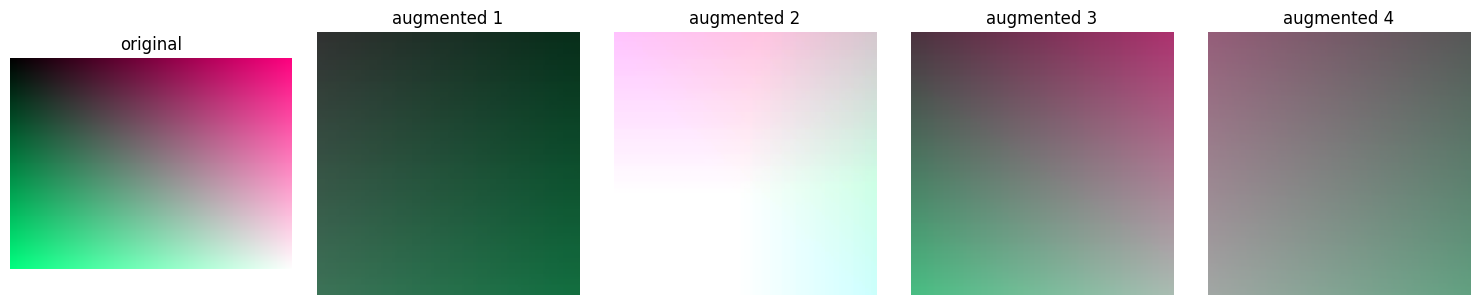

augmentation pipeline check passed


In [4]:
from PIL import Image
from torchvision import transforms


augmentation = transforms.Compose(
    [
        transforms.RandomResizedCrop(224, scale=(0.08, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
        transforms.ToTensor(),
    ]
)

# 生成一张 320x240 RGB 渐变测试图。
width, height = 320, 240
x_grid = np.linspace(0, 255, width, dtype=np.uint8)
y_grid = np.linspace(0, 255, height, dtype=np.uint8)
red = np.tile(x_grid, (height, 1))
green = np.tile(y_grid[:, None], (1, width))
blue = ((red.astype(np.uint16) + green.astype(np.uint16)) // 2).astype(np.uint8)
demo_image = Image.fromarray(np.stack([red, green, blue], axis=-1))

augmented_images = [augmentation(demo_image) for _ in range(4)]
print("original image size:", demo_image.size)
for i, image_tensor in enumerate(augmented_images, start=1):
    print(
        f"augmented {i}: shape={tuple(image_tensor.shape)}, "
        f"range=({image_tensor.min().item():.3f}, {image_tensor.max().item():.3f})"
    )

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(demo_image)
axes[0].set_title("original")
for i, image_tensor in enumerate(augmented_images, start=1):
    axes[i].imshow(image_tensor.permute(1, 2, 0).clamp(0, 1))
    axes[i].set_title(f"augmented {i}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

assert all(image.shape == (3, 224, 224) for image in augmented_images)
print("augmentation pipeline check passed")

---

## 6. 目标检测、计算机视觉训练技巧

### 6.1 理论计算题

两个边界框的交集左上角为 $(30,30)$，右下角为 $(50,50)$，所以交集面积为

$$
S_{\mathrm{intersection}}=(50-30)(50-30)=400.
$$

两个边界框各自面积都是

$$
S_A=S_B=(50-10)^2=(70-30)^2=1600.
$$

并集面积为

$$
S_{\mathrm{union}}=S_A+S_B-S_{\mathrm{intersection}}
=1600+1600-400=2800.
$$

因此

$$
\operatorname{IoU}(A,B)
=\frac{400}{2800}
=\boxed{\frac17\approx0.142857}.
$$

### 6.2 编程题：标签平滑交叉熵

对 $K$ 分类问题，真实类别概率设为 $1-\epsilon$，其余每类概率设为
$\epsilon/(K-1)$。先构造平滑后的目标分布，再与 `log_softmax` 计算交叉熵。

In [5]:
def label_smoothing_cross_entropy(logits, targets, epsilon=0.1):
    if logits.dim() != 2:
        raise ValueError("logits must have shape (batch_size, num_classes)")
    if not 0 <= epsilon < 1:
        raise ValueError("epsilon must satisfy 0 <= epsilon < 1")

    num_classes = logits.shape[1]
    if num_classes < 2:
        raise ValueError("label smoothing requires at least two classes")

    with torch.no_grad():
        smooth_targets = torch.full_like(
            logits, fill_value=epsilon / (num_classes - 1)
        )
        smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - epsilon)

    log_probs = F.log_softmax(logits, dim=1)
    per_sample_loss = -(smooth_targets * log_probs).sum(dim=1)
    return per_sample_loss.mean()


logits = torch.tensor(
    [
        [4.0, 1.0, 0.0],
        [0.5, 2.0, -1.0],
        [1.0, 0.0, 3.0],
    ],
    requires_grad=True,
)
targets = torch.tensor([0, 1, 2])

smoothed_loss = label_smoothing_cross_entropy(logits, targets, epsilon=0.1)
with torch.no_grad():
    smooth_targets = torch.full_like(logits, 0.1 / (logits.shape[1] - 1))
    smooth_targets.scatter_(1, targets.unsqueeze(1), 0.9)
ordinary_loss = F.cross_entropy(logits, targets)
smoothed_loss.backward()

print("smoothed target distributions:")
print(smooth_targets)
print(f"ordinary cross entropy: {ordinary_loss.item():.6f}")
print(f"label-smoothed loss:    {smoothed_loss.item():.6f}")
print("logits gradient:")
print(logits.grad)

assert torch.allclose(smooth_targets.sum(dim=1), torch.ones(3))
assert torch.allclose(
    smooth_targets,
    torch.tensor(
        [
            [0.90, 0.05, 0.05],
            [0.05, 0.90, 0.05],
            [0.05, 0.05, 0.90],
        ]
    ),
)
print("label smoothing checks passed")

smoothed target distributions:
tensor([[0.9000, 0.0500, 0.0500],
        [0.0500, 0.9000, 0.0500],
        [0.0500, 0.0500, 0.9000]])
ordinary cross entropy: 0.159014
label-smoothed loss:    0.434014
logits gradient:
tensor([[ 0.0121, -0.0011, -0.0110],
        [ 0.0418, -0.0381, -0.0036],
        [ 0.0214, -0.0027, -0.0187]])
label smoothing checks passed
